In [1]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from PIL import Image
import torch
from qwen_vl_utils import process_vision_info
import json
from typing import Dict, List

model_path = "../saves/qwen2_5vl-7b/full/sft_artifacts_gpt"  # ← update as needed

processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct", trust_remote_code=True)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,           # or "auto" or float16
    device_map="auto",                    # auto-distributes across GPUs
    trust_remote_code=True
).eval()

/home/jovyan/conda/lfac/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.
Loading checkpoint shards: 100%|██████████| 4/4 [00:03<00:00,  1.22it/s]


In [2]:
def parse_json(bbox_str: str) -> Dict:
    """Parse the JSON string containing bbox and explanation data."""
    try:
        # Extract JSON from the string (remove ```json and ```)
        json_str = bbox_str.strip()
        if json_str.startswith('```json'):
            json_str = json_str[7:]
        if json_str.endswith('```'):
            json_str = json_str[:-3]
        
        return json.loads(json_str.strip())
    except json.JSONDecodeError as e:
        print(f"Error parsing JSON: {e}")
        return {}

def chat(image_path, processor, model):
    image = Image.open(image_path).convert("RGB")

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": "Analyze the image and describe any visual anomalies. Provide bounding boxes, and the type of artifact."}
            ],
        }
    ]

    text_input = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text_input],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(model.device)


    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=512)

    generated_ids_trimmed = [
        output[len(inputs["input_ids"][i]):] for i, output in enumerate(generated_ids)
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return output_text

In [3]:
# open_ended_vqa_viewer.ipynb

# 1. Import required modules
import json
from PIL import Image
from IPython.display import display
import os

# 2. Load the JSON configuration
json_path = "/home/jovyan/image-artifacts/data/loki/open_ended_vqa.json"
base_dir = os.path.dirname(json_path)

with open(json_path, "rb") as f:
    data = json.load(f)

sample_iter = iter(data)

{'bbox_2d': [0, 16, 159, 271], 'artifact_type': 'removal', 'explanation': 'In the highlighted region, the tree appears to be missing or significantly altered. There is an unnatural gap where the tree should be, creating a discontinuity in the forested area. The surrounding foliage seems to be smoothed over, lacking the expected structure and detail of a tree.'}


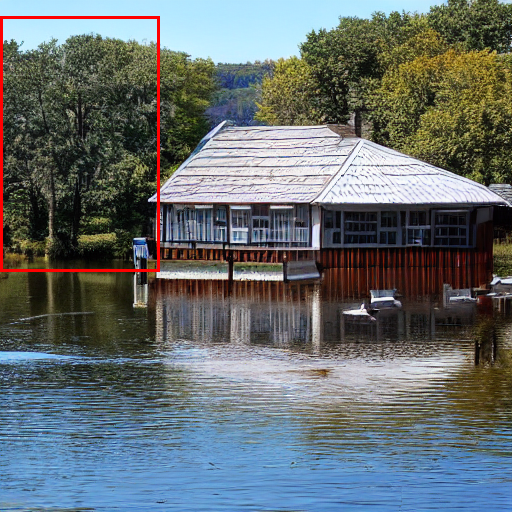

In [4]:
import os
import numpy as np
from PIL import Image, ImageDraw
import cv2

# Example sample input
sample = next(sample_iter)
image_path = os.path.join(base_dir, sample["image_path"])


# Assuming this returns a list of bbox results
result = parse_json(chat(image_path, processor, model))[0]
print(result)

# Draw bounding box
bbox = result['bbox_2d']  # assuming the bbox is under this key
xmin, ymin, xmax, ymax = bbox

# Create a drawable image
image = Image.open(image_path)
draw = ImageDraw.Draw(image)

# Draw rectangle
draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=3)

# Show or save the resulting image
image.show()
# image.save("output_with_bbox.jpg")  # optional save